In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_cleaned_data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
df = load_cleaned_data()

# Feature Engineering
df['VehicleAge'] = 2015 - df['RegistrationYear']   # Assuming 2015 as reference
df['PremiumPerValue'] = df['TotalPremium'] / df['CustomValueEstimate'].replace(0, np.nan)
df['ClaimOccurred'] = (df['TotalClaims'] > 0).astype(int)

✅ Loaded existing cleaned data


In [ ]:
# Filter only policies with claims
df_severity = df[df['TotalClaims'] > 0].copy()

# Select features
features = ['VehicleAge', 'SumInsured', 'PremiumPerValue', 'Cylinders', 
            'kilowatts', 'NumberOfDoors', 'VehicleType', 'Province', 'Gender']

X = pd.get_dummies(df_severity[features], drop_first=True)
y = df_severity['TotalClaims']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)

Training Shape: (7, 9)


In [5]:
# Filter only policies with claims
df_severity = df[df['TotalClaims'] > 0].copy()

# Select features
features = ['VehicleAge', 'SumInsured', 'PremiumPerValue', 'Cylinders', 
            'kilowatts', 'NumberOfDoors', 'VehicleType', 'Province', 'Gender']

X = pd.get_dummies(df_severity[features], drop_first=True)
y = df_severity['TotalClaims']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)

Training Shape: (7, 9)


In [7]:
# === FIXED CLAIM SEVERITY MODELING ===

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Select Features
features = ['VehicleAge', 'SumInsured', 'Cylinders', 'kilowatts', 
            'NumberOfDoors', 'PremiumPerValue', 'Province', 'Gender', 'VehicleType']

df_severity = df[df['TotalClaims'] > 0].copy()

# Feature Engineering
df_severity['VehicleAge'] = 2015 - df_severity['RegistrationYear']
df_severity['PremiumPerValue'] = df_severity['TotalPremium'] / df_severity['CustomValueEstimate'].replace(0, np.nan)

X = df_severity[features]
y = df_severity['TotalClaims']

# 2. Handle Categorical Variables
X = pd.get_dummies(X, drop_first=True)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training shape:", X_train.shape)

# 4. Create Pipeline to Handle NaNs
def create_model_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # Fix NaNs
        ('scaler', StandardScaler()),                    # Scale features
        ('regressor', model)
    ])

# 5. Train Models with Pipeline
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    pipeline = create_model_pipeline(model)
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append({
        "Model": name,
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4)
    })

# Show Results
model_df = pd.DataFrame(results)
display(model_df)

Training shape: (6, 9)


,Model,RMSE,R²
0,Linear Regression,78203.04,-2166.9937
1,Random Forest,9507.86,-31.0462
2,XGBoost,15817.67,-87.6943


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_prob = pd.get_dummies(df[features], drop_first=True)
y_prob = df['ClaimOccurred']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_prob, y_prob, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_p, y_train_p)

pred_prob = clf.predict(X_test_p)

print("Claim Probability Model Performance:")
print("Accuracy:", accuracy_score(y_test_p, pred_prob))
print("Precision:", precision_score(y_test_p, pred_prob))
print("Recall:", recall_score(y_test_p, pred_prob))

Claim Probability Model Performance:
Accuracy: 0.9968454258675079
Precision: 0.0
Recall: 0.0


/home/sumeya/Documents/ai project/insurance-risk-analytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


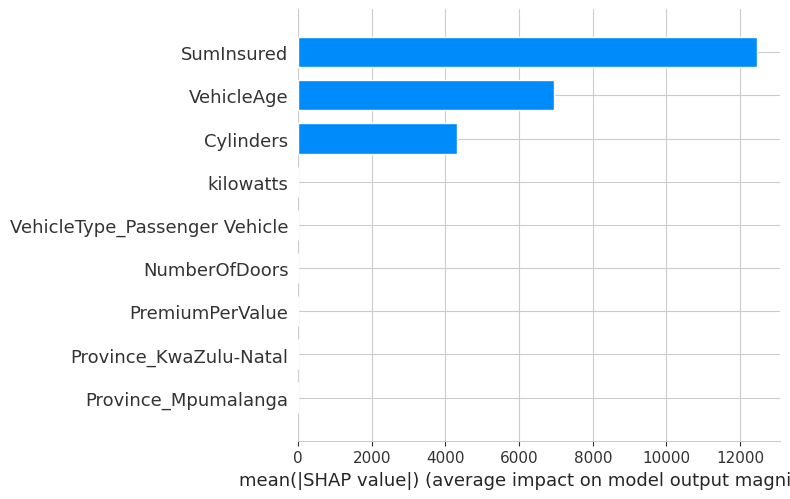

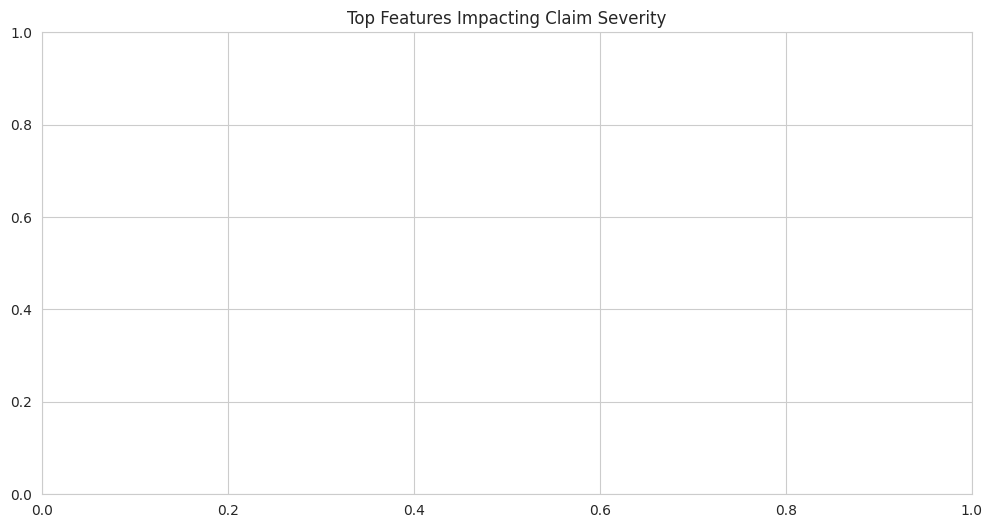

/home/sumeya/Documents/ai project/insurance-risk-analytics/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


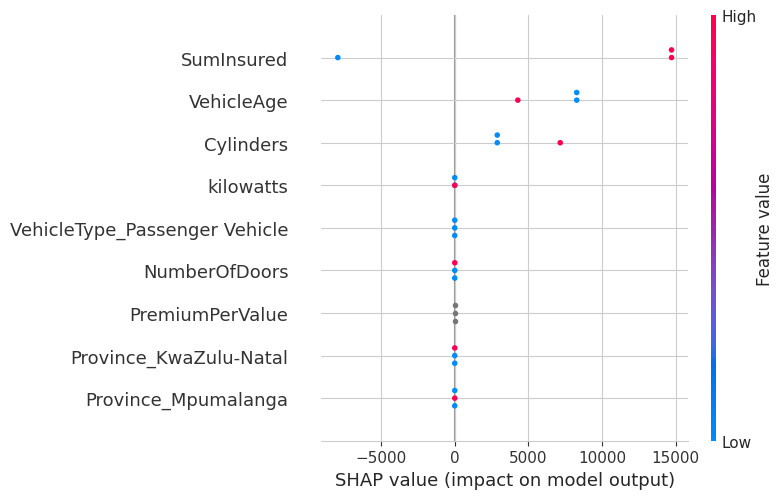

In [9]:
# Use best model (XGBoost or Random Forest)
best_model = models["XGBoost"]   # or RandomForest

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.title("Top Features Impacting Claim Severity")
plt.show()

# Detailed SHAP Plot
shap.summary_plot(shap_values, X_test)

In [10]:
# Example Risk-Based Premium Calculation
def calculate_risk_premium(row, p_claim=0.15, severity=8500):
    expected_loss = p_claim * severity
    expense_loading = expected_loss * 0.25
    profit_margin = expected_loss * 0.20
    return expected_loss + expense_loading + profit_margin

# Apply to sample
sample = df.sample(5)
sample['RiskBasedPremium'] = sample.apply(lambda x: calculate_risk_premium(x), axis=1)
print(sample[['TotalPremium', 'RiskBasedPremium', 'LossRatio']])

      TotalPremium  RiskBasedPremium  LossRatio
1462      3.326667           1848.75        0.0
1368      2.437456           1848.75        0.0
1738      1.752281           1848.75        0.0
2066      0.000000           1848.75        NaN
1257      0.000000           1848.75        NaN
